## REGULARIZATION & HYPERPARAMETER TUNING

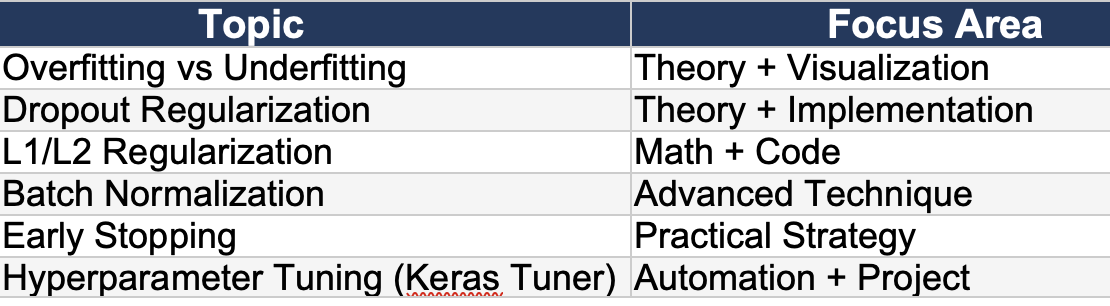

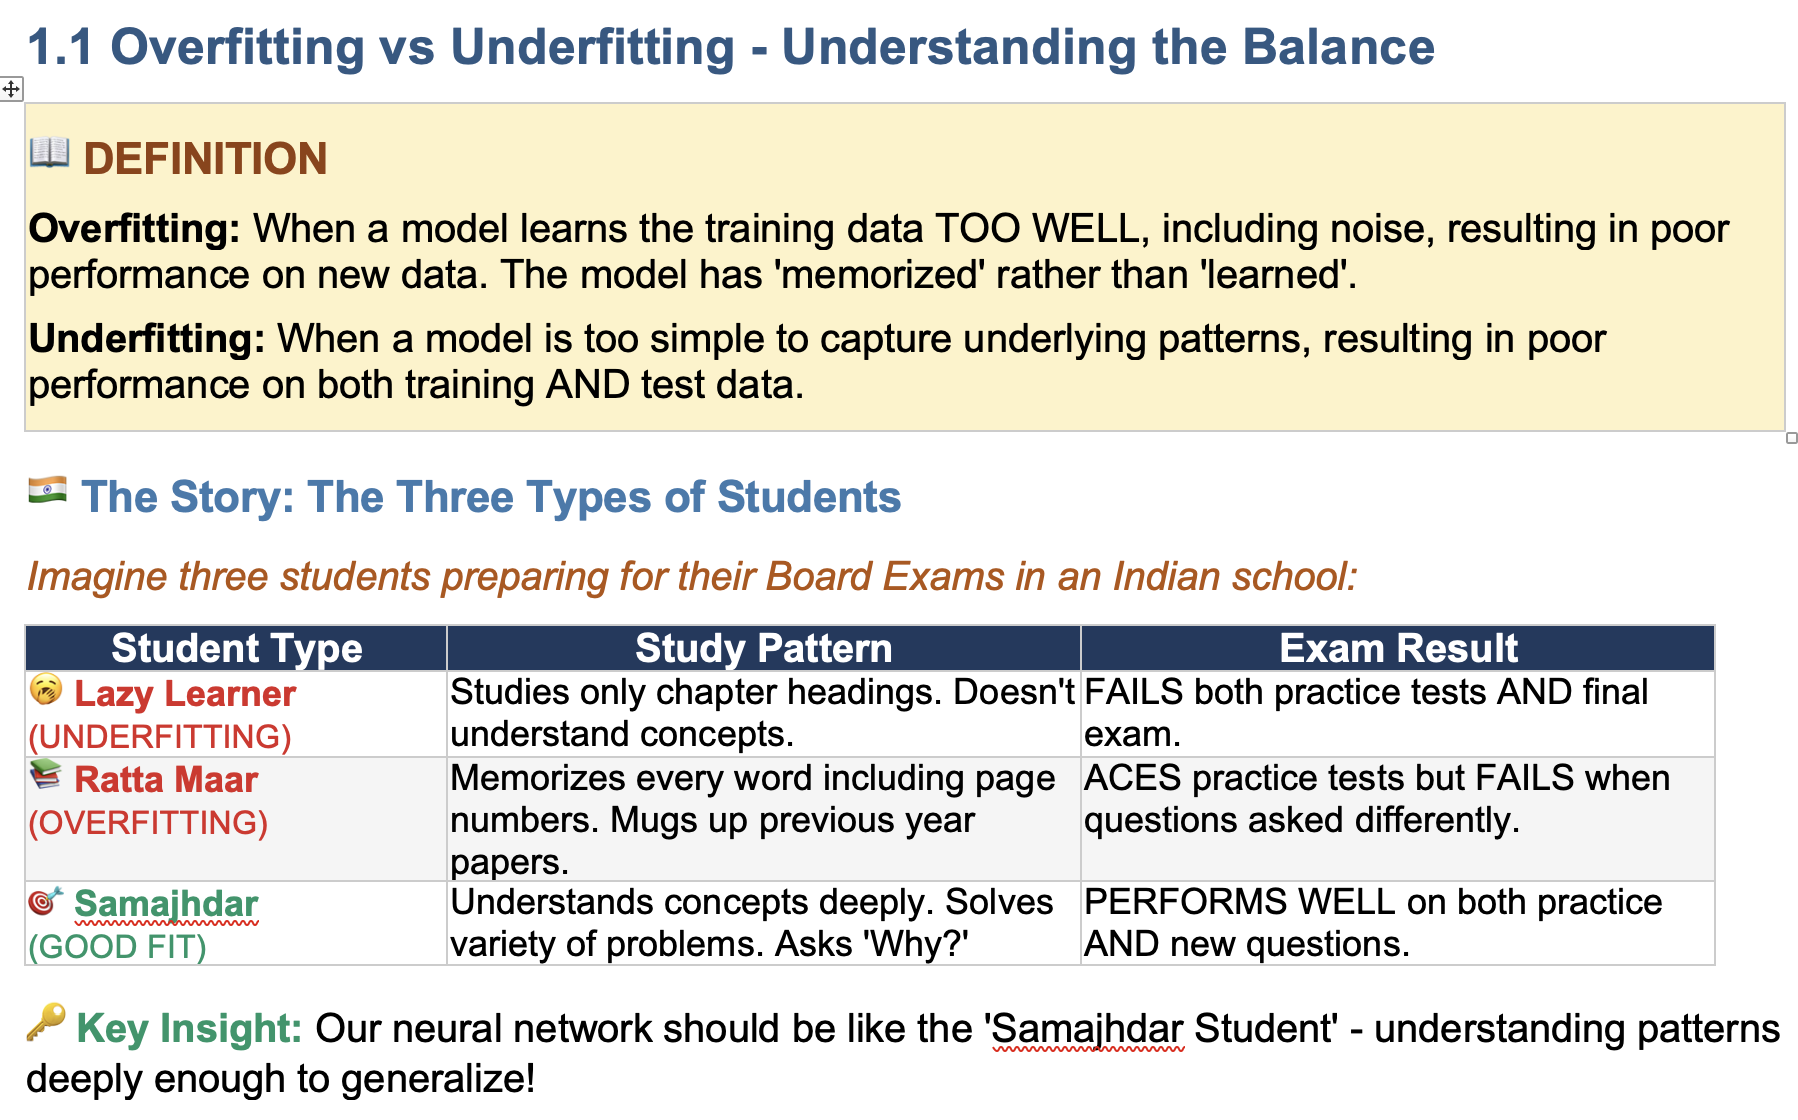

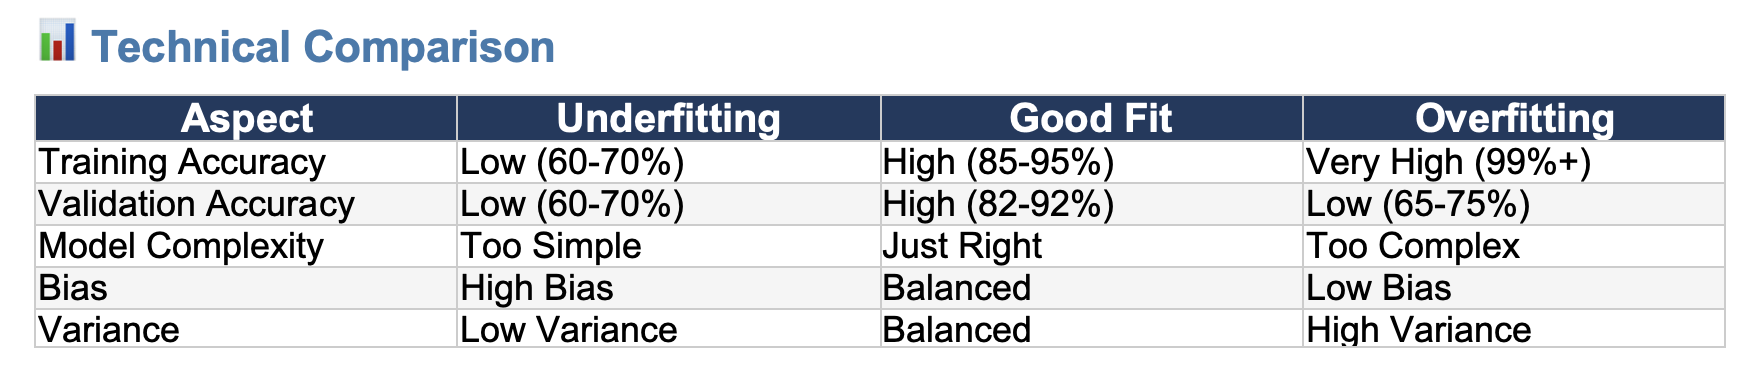

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2, l1_l2
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# =============================================================================
# EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING (🟢 EASY)
# Indian Analogy: Three Types of Students
# =============================================================================
print("\n" + "=" * 60)
print("EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING")
print("Indian Analogy: The Three Types of Students")
print("=" * 60)

# Generate sample data (Moon dataset - like two chapatis!)
print("\n📊 Generating Moon Dataset...")
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train_moon, X_val_moon, y_train_moon, y_val_moon = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train_moon)}, Validation samples: {len(X_val_moon)}")


EXAMPLE 1: DETECTING OVERFITTING VS UNDERFITTING
Indian Analogy: The Three Types of Students

📊 Generating Moon Dataset...
Training samples: 400, Validation samples: 100


In [3]:
# MODEL 1: UNDERFITTING (Too Simple - Lazy Student / आलसी विद्यार्थी)
print("\n🥱 Creating UNDERFITTING Model (Lazy Student)...")
underfit_model = keras.Sequential([
    layers.Dense(2, activation='relu', input_shape=(2,)),  # Too few neurons!
    layers.Dense(1, activation='sigmoid')
], name='Underfit_Lazy_Student')



🥱 Creating UNDERFITTING Model (Lazy Student)...


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# MODEL 2: OVERFITTING (Too Complex - Ratta Maar / रट्टा मार)
print("📚 Creating OVERFITTING Model (Ratta Maar)...")
overfit_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(2,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),  # Way too many neurons!
    layers.Dense(1, activation='sigmoid')
], name='Overfit_Ratta_Maar')

📚 Creating OVERFITTING Model (Ratta Maar)...


In [5]:
# MODEL 3: GOOD FIT (Just Right - Samajhdar / समझदार विद्यार्थी)
print("🎯 Creating GOOD FIT Model (Samajhdar Student)...")
goodfit_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='GoodFit_Samajhdar')

🎯 Creating GOOD FIT Model (Samajhdar Student)...


In [6]:
# Compile all models
for model in [underfit_model, overfit_model, goodfit_model]:
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )


In [7]:
# Train and capture history
print("\n🏋️ Training all three models...")
history_under = underfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)

history_over = overfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)

history_good = goodfit_model.fit(
    X_train_moon, y_train_moon,
    validation_data=(X_val_moon, y_val_moon),
    epochs=100, verbose=0
)


🏋️ Training all three models...


In [8]:
# Visualization function
def plot_learning_curves(history, title, ax1, ax2):
    """Plot training vs validation loss and accuracy"""
    # Plot Loss
    ax1.plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss Curves')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(history.history['accuracy'], 'b-', label='Training Acc', linewidth=2)
    ax2.plot(history.history['val_accuracy'], 'r--', label='Validation Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy Curves')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# Create visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

plot_learning_curves(history_under, 'UNDERFITTING (Lazy Student)', axes[0, 0], axes[0, 1])
plot_learning_curves(history_over, 'OVERFITTING (Ratta Maar)', axes[1, 0], axes[1, 1])
plot_learning_curves(history_good, 'GOOD FIT (Samajhdar)', axes[2, 0], axes[2, 1])

plt.tight_layout()
plt.savefig('Day09_Example1_Overfitting_Detection.png', dpi=150, bbox_inches='tight')
plt.close()
print("✅ Visualization saved: Day09_Example1_Overfitting_Detection.png")


✅ Visualization saved: Day09_Example1_Overfitting_Detection.png


In [9]:
# Print results
print("\n📊 RESULTS COMPARISON:")
print("-" * 50)
print(f"{'Model':<25} {'Train Acc':<15} {'Val Acc':<15}")
print("-" * 50)
print(f"{'Underfit (Lazy)':<25} {history_under.history['accuracy'][-1]:.4f}         {history_under.history['val_accuracy'][-1]:.4f}")
print(f"{'Overfit (Ratta Maar)':<25} {history_over.history['accuracy'][-1]:.4f}         {history_over.history['val_accuracy'][-1]:.4f}")
print(f"{'Good Fit (Samajhdar)':<25} {history_good.history['accuracy'][-1]:.4f}         {history_good.history['val_accuracy'][-1]:.4f}")


📊 RESULTS COMPARISON:
--------------------------------------------------
Model                     Train Acc       Val Acc        
--------------------------------------------------
Underfit (Lazy)           0.8400         0.8700
Overfit (Ratta Maar)      0.9850         0.9500
Good Fit (Samajhdar)      0.9825         0.9800
